In [47]:
import os
import sys
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
# Seed
random.seed(42)
np.random.seed(42)

In [38]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'tabular', 'real', 'lattice_physics')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints', 'tabular', 'real', 'lattice_physics')
OUT_PATH = os.path.join(CURRENT_DIR, 'out', 'tabular', 'real', 'lattice_physics')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [39]:
df_data = pd.read_csv(os.path.join(DATA_PATH, 'raw.csv'), header=None, sep='\s+')
df_data

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,1.32630,1.862086,3.562615,1.112359,4.208065,1.412679,2.271031,3.950614,3.627032,4.600332,...,3.965987,4.030999,0.826347,2.088521,4.088550,1.184149,2.780985,2.865400,4.773820,3.539373
1,1.34149,1.786558,2.354766,1.047929,2.268974,4.637777,3.793194,2.859702,4.361058,3.592485,...,2.228000,4.837370,2.846538,3.413201,4.154079,4.700800,3.597879,4.681148,3.215494,3.972672
2,1.33034,1.826187,3.037997,4.719517,1.502280,3.644736,3.575727,1.337686,2.380347,4.503771,...,2.615278,3.757999,3.161658,4.996056,3.339642,2.548468,4.417111,1.375554,4.363320,2.988546
3,1.35653,1.739225,4.412804,2.220680,3.132738,1.327124,4.759890,2.882082,3.663430,4.531524,...,3.899026,1.018926,4.379308,3.280298,3.916281,3.179922,3.769315,0.849544,2.508179,0.912272
4,1.30190,1.955829,2.790669,0.798177,1.231750,1.977844,2.393930,4.738126,1.364743,3.391665,...,3.641512,1.564076,2.178406,2.754888,4.007165,0.702069,4.064682,1.370575,0.769475,1.395959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,1.34544,1.743127,4.621978,0.963192,4.210216,3.423779,2.192868,3.508347,3.386905,3.968789,...,1.638597,4.678428,4.586518,3.525760,3.016039,2.293887,2.873119,2.826376,4.330362,4.674605
23996,1.31199,2.044305,2.041864,1.259900,2.142008,4.177358,2.687296,0.706699,1.023353,0.816572,...,3.776626,4.615394,4.139275,3.443595,0.832678,4.899376,3.968322,1.738017,3.226694,3.452317
23997,1.31469,1.812564,1.830439,4.867422,3.724882,3.449326,1.832762,2.795601,3.765395,3.784611,...,1.833866,2.118985,2.966005,0.837887,3.715409,4.211463,2.217214,4.945882,3.656180,2.519797
23998,1.29903,1.987031,1.465316,2.609561,3.315532,0.861328,2.473849,4.993416,4.305993,1.496657,...,4.115641,1.466984,4.082933,1.479720,3.851738,1.770131,1.344583,4.066575,4.523322,3.435312


In [40]:
df_data.columns =['k-inf', 'pppf'] + [f'C{col}' for col in df_data.columns[2:]]

In [41]:
df_data.duplicated().sum(), df_data.isna().sum().sum()

(0, 0)

In [42]:
df_data.nunique()

k-inf     7209
pppf     24000
C2       24000
C3       24000
C4       24000
C5       24000
C6       24000
C7       24000
C8       24000
C9       24000
C10      24000
C11      24000
C12      24000
C13      24000
C14      24000
C15      24000
C16      23999
C17      24000
C18      24000
C19      24000
C20      24000
C21      24000
C22      24000
C23      24000
C24      24000
C25      24000
C26      24000
C27      24000
C28      24000
C29      24000
C30      24000
C31      24000
C32      24000
C33      24000
C34      24000
C35      24000
C36      24000
C37      24000
C38      24000
C39      24000
C40      24000
dtype: int64

In [43]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
k-inf,24000.0,1.325139,0.017798,1.246360,1.313650,1.326085,1.337683,1.385580
pppf,24000.0,1.883559,0.120018,1.527497,1.798641,1.876336,1.960852,2.473015
C2,24000.0,2.855694,1.240040,0.700055,1.778343,2.855621,3.935998,4.999537
C3,24000.0,2.859994,1.238304,0.700098,1.784898,2.869736,3.931073,4.999781
C4,24000.0,2.857451,1.237204,0.700080,1.785185,2.873263,3.921500,4.999613
C5,24000.0,2.867554,1.234584,0.700019,1.805416,2.875835,3.939858,4.999984
C6,24000.0,2.848997,1.243988,0.700079,1.767307,2.844372,3.918052,4.999956
C7,24000.0,2.840123,1.242275,0.700042,1.763301,2.841756,3.918678,4.999745
C8,24000.0,2.867360,1.242041,0.700169,1.784607,2.885330,3.938584,4.999930
C9,24000.0,2.850948,1.243739,0.700152,1.768854,2.852607,3.927791,4.999936


In [44]:
columnas_categoricas = df_data.select_dtypes(include=['object', 'category']).columns
list(columnas_categoricas)

[]

<Axes: >

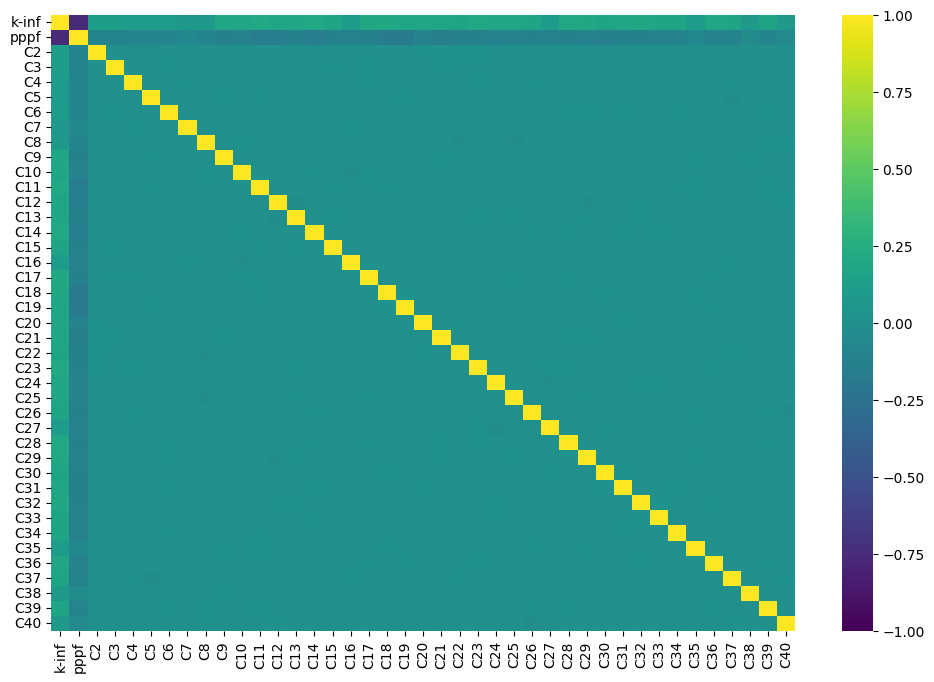

In [49]:
corr = df_data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="viridis", vmax=1, vmin=-1)

In [50]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)